In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.ensemble import RandomForestClassifier

In [3]:
df=pd.read_csv('../kdd2004.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,target
0,52.0,32.69,0.30,2.5,20.0,1256.8,-0.89,0.33,11.0,-55.0,...,1595.1,-1.64,2.83,-2.0,-50.0,445.2,-0.35,0.26,0.76,-1
1,58.0,33.33,0.00,16.5,9.5,608.1,0.50,0.07,20.5,-52.5,...,762.9,0.29,0.82,-3.0,-35.0,140.3,1.16,0.39,0.73,-1
2,77.0,27.27,-0.91,6.0,58.5,1623.6,-1.40,0.02,-6.5,-48.0,...,1491.8,0.32,-1.29,0.0,-34.0,658.2,-0.76,0.26,0.24,-1
3,41.0,27.91,-0.35,3.0,46.0,1921.6,-1.36,-0.47,-32.0,-51.5,...,2047.7,-0.98,1.53,0.0,-49.0,554.2,-0.83,0.39,0.73,-1
4,50.0,28.00,-1.32,-9.0,12.0,464.8,0.88,0.19,8.0,-51.5,...,479.5,0.68,-0.59,2.0,-36.0,-6.9,2.02,0.14,-0.23,-1


In [4]:
df.target = df.target.map({-1:0, 1:1})
df.target.value_counts()

target
0    144455
1      1296
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df.target, test_size=0.3, random_state=0)

In [7]:
X_train.shape, X_test.shape

((102025, 74), (43726, 74))

In [8]:
import imblearn.under_sampling 

In [9]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [10]:
from imblearn.under_sampling import OneSidedSelection

In [11]:
?OneSidedSelection

Init signature:
OneSidedSelection(
    *,
    sampling_strategy='auto',
    random_state=None,
    n_neighbors=None,
    n_seeds_S=1,
    n_jobs=None,
)
Docstring:     
Class to perform under-sampling based on one-sided selection method.

Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function t

In [12]:
oss = OneSidedSelection(sampling_strategy='auto',
                        random_state=0,
                        n_neighbors=1,
                        n_jobs=-1)

X_resampled, y_resampled = oss.fit_resample(X_train, y_train)

In [13]:
X_train.shape, X_resampled.shape

((102025, 74), (101769, 74))

In [14]:
# plt.figure(figsize=(15,6))
# plt.subplot(121)
# sns.scatterplot(x='0', y='1', data=X_train, hue=y_train)

# plt.subplot(122)
# sns.scatterplot(x='0', y='1', data=X_resampled, hue=y_resampled)

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
?RandomForestClassifier

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

In [17]:
from matplotlib.colors import ListedColormap

In [18]:
X_train2D = X_train.iloc[:1000,:2]
y_train = y_train.iloc[:1000]

In [19]:
oss = OneSidedSelection(sampling_strategy='auto',
                        random_state=0,
                        n_neighbors=1,
                        n_jobs=-1)

X_resampled, y_resampled = oss.fit_resample(X_train2D, y_train)

In [20]:
rf = RandomForestClassifier(n_estimators=200, criterion='entropy', 
                            max_depth=4,
                            random_state=0,
                            n_jobs=-1)

rf.fit(X_train2D, y_train)

RandomForestClassifier(criterion='entropy', max_depth=4, n_estimators=200,
                       n_jobs=-1, random_state=0)

In [21]:
rf_oss = RandomForestClassifier(n_estimators=200,
                                criterion='entropy',
                                max_depth=4,
                                random_state=0,
                                n_jobs=-1)

rf_oss.fit(X_resampled, y_resampled)

RandomForestClassifier(criterion='entropy', max_depth=4, n_estimators=200,
                       n_jobs=-1, random_state=0)

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


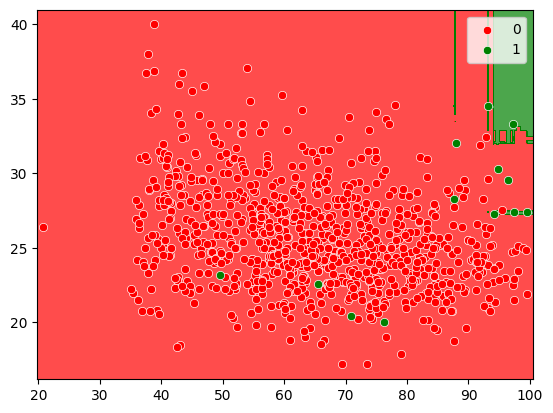

In [24]:
X_set, y_set = X_resampled.values, y_resampled

colors=('red', 'green')
cmap=ListedColormap(colors)


X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
step=0.01

X1, X2 = np.meshgrid(
                    np.arange(X1_min, X1_max, step),
                    np.arange(X2_min, X2_max, step)
)


arr = np.array([X1.ravel(), X2.ravel()])
Z = rf.predict(arr.T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.7, cmap=cmap)

for i, j in enumerate(np.unique(y_set)):

    xi = X_set[y_set==j,0]
    yi = X_set[y_set==j,1]

    sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)

In [23]:
y_train.value_counts()

target
0    987
1     13
Name: count, dtype: int64

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


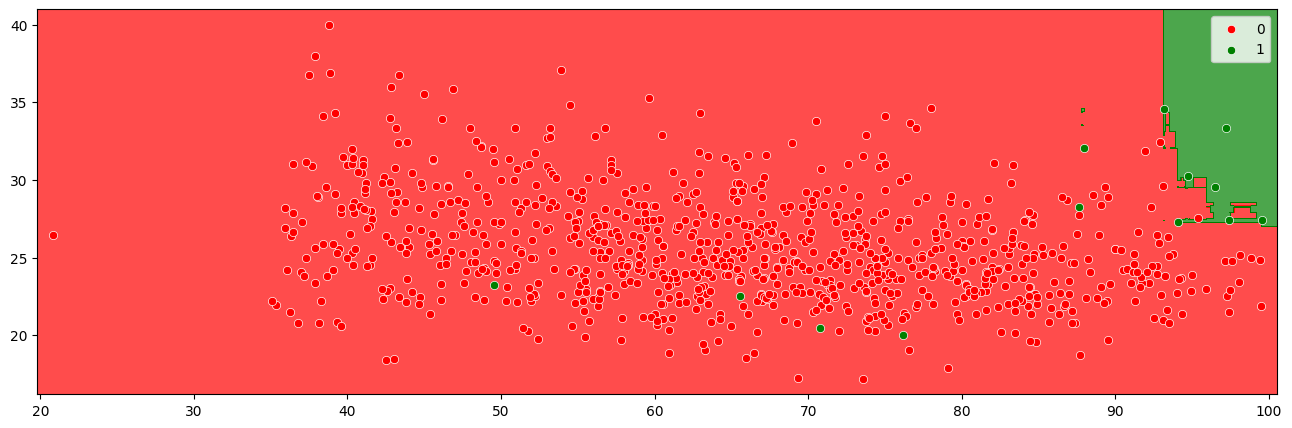

In [25]:
plt.figure(figsize=(16,5))
X_set, y_set = X_resampled.values, y_resampled

colors=('red', 'green')
cmap=ListedColormap(colors)


X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
step=0.01

X1, X2 = np.meshgrid(
                    np.arange(X1_min, X1_max, step),
                    np.arange(X2_min, X2_max, step)
)


arr = np.array([X1.ravel(), X2.ravel()])
Z = rf_oss.predict(arr.T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.7, cmap=cmap)

for i, j in enumerate(np.unique(y_set)):

    xi = X_set[y_set==j,0]
    yi = X_set[y_set==j,1]

    sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


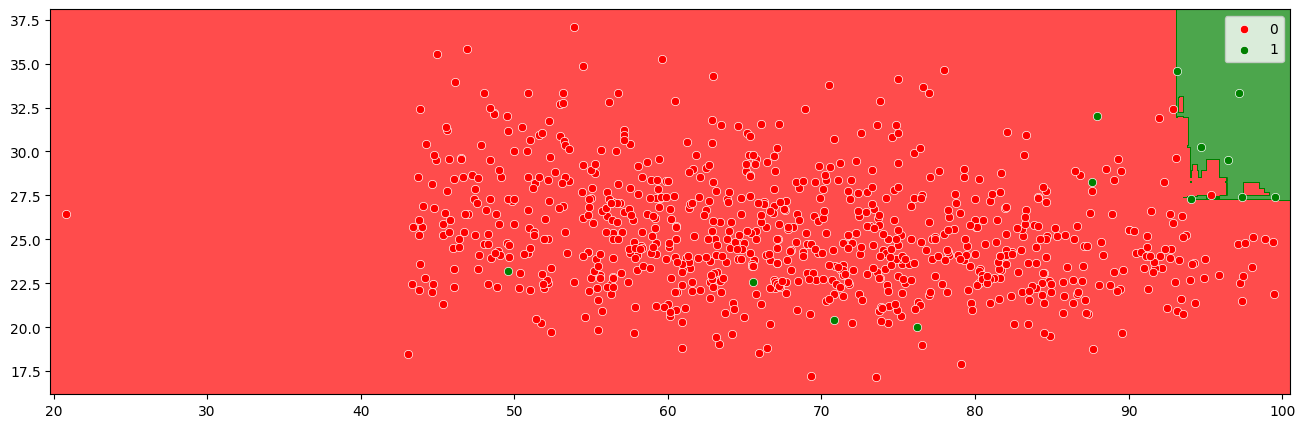

In [26]:
oss = OneSidedSelection(sampling_strategy='auto',
                        random_state=0,
                        n_neighbors=2,
                        n_jobs=-1)

X_resampled, y_resampled = oss.fit_resample(X_train2D, y_train)

rf_oss = RandomForestClassifier(n_estimators=200,
                                criterion='entropy',
                                max_depth=4,
                                random_state=0,
                                n_jobs=-1)

rf_oss.fit(X_resampled, y_resampled)

plt.figure(figsize=(16,5))
X_set, y_set = X_resampled.values, y_resampled

colors=('red', 'green')
cmap=ListedColormap(colors)


X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
step=0.01

X1, X2 = np.meshgrid(
                    np.arange(X1_min, X1_max, step),
                    np.arange(X2_min, X2_max, step)
)


arr = np.array([X1.ravel(), X2.ravel()])
Z = rf_oss.predict(arr.T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.7, cmap=cmap)

for i, j in enumerate(np.unique(y_set)):

    xi = X_set[y_set==j,0]
    yi = X_set[y_set==j,1]

    sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)

In [29]:
from sklearn.svm import SVC

In [30]:
svm = SVC()

In [32]:
?SVC

Init signature:
SVC(
    *,
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=None,
)
Docstring:     
C-Support Vector Classification.

The implementation is based on libsvm. The fit time scales at least
quadratically with the number of samples and may be impractical
beyond tens of thousands of samples. For large datasets
consider using :class:`~sklearn.svm.LinearSVC` or
:class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
:class:`~sklearn.kernel_approximation.Nystroem` transformer or
other :ref:`kernel_approximation`.

The multiclass support is handled according to a one-vs-one scheme.

For details on the precise mathematical formulation of the provided
kernel functions and how `gamma`, `coef0` and `degree` affect each
other, see the

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


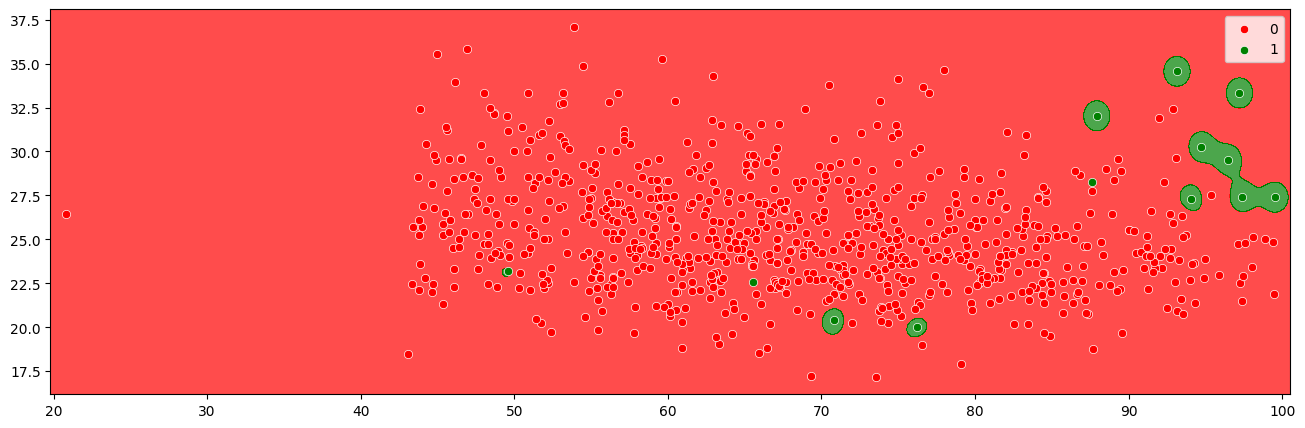

In [33]:
oss = OneSidedSelection(sampling_strategy='auto',
                        random_state=0,
                        n_neighbors=2,
                        n_jobs=-1)

X_resampled, y_resampled = oss.fit_resample(X_train2D, y_train)

rf_oss = SVC(gamma=1, C=2)

rf_oss.fit(X_resampled, y_resampled)

plt.figure(figsize=(16,5))
X_set, y_set = X_resampled.values, y_resampled

colors=('red', 'green')
cmap=ListedColormap(colors)


X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
step=0.01

X1, X2 = np.meshgrid(
                    np.arange(X1_min, X1_max, step),
                    np.arange(X2_min, X2_max, step)
)


arr = np.array([X1.ravel(), X2.ravel()])
Z = rf_oss.predict(arr.T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.7, cmap=cmap)

for i, j in enumerate(np.unique(y_set)):

    xi = X_set[y_set==j,0]
    yi = X_set[y_set==j,1]

    sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)